<a href="https://colab.research.google.com/github/ahmad-raka-alkindi/AHMAD-RAKA-ALKINDI_2411533017_ML2526/blob/main/praktikum3/tugas_praktikum_pekan_3_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. import library

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
sns.set_style("darkgrid")

2. load dataset

In [15]:
dataset_url = 'https://raw.githubusercontent.com/ahmad-raka-alkindi/AHMAD-RAKA-ALKINDI_2411533017_ML2526/refs/heads/main/praktikum2/Breast_cancer_data.csv'
df = pd.read_csv(dataset_url)
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


3. memisahkan variabel independen dan variabel dependen atau fitur dan target

In [16]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=16)

4. scalling dataset

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

5. pelatihan model

In [18]:
# Inisialisasi model
logreg = LogisticRegression()

# Latih model pada data yang sudah discaling
logreg.fit(X_train_scaled, y_train)

# Prediksi probabilitas untuk kelas 1
y_pred_proba = logreg.predict_proba(X_test_scaled)[:, 1]

6. eksperimenn threshold dan evaluasi


==================== Threshold: 0.3 ====================
Accuracy: 0.935672514619883

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91        65
           1       0.91      0.99      0.95       106

    accuracy                           0.94       171
   macro avg       0.95      0.92      0.93       171
weighted avg       0.94      0.94      0.93       171



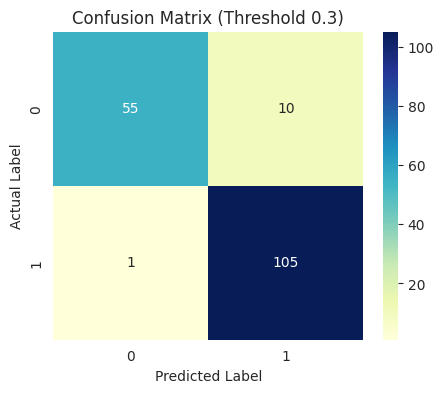


==================== Threshold: 0.5 ====================
Accuracy: 0.9415204678362573

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        65
           1       0.94      0.96      0.95       106

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



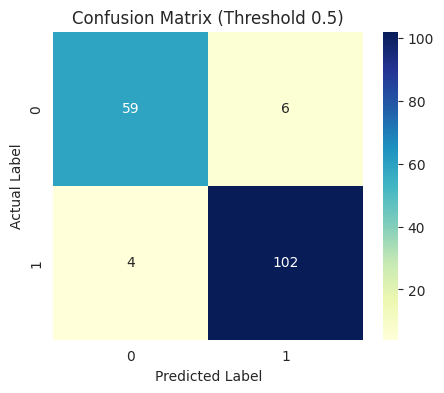


==================== Threshold: 0.7 ====================
Accuracy: 0.9122807017543859

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89        65
           1       0.96      0.90      0.93       106

    accuracy                           0.91       171
   macro avg       0.90      0.92      0.91       171
weighted avg       0.92      0.91      0.91       171



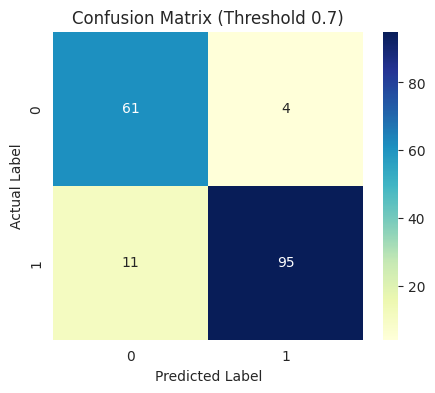

In [19]:
def evaluasi_model(threshold):
    # Mengubah probabilitas menjadi prediksi berdasarkan threshold
    y_pred = (y_pred_proba >= threshold).astype(int)

    print(f"\n{'='*20} Threshold: {threshold} {'='*20}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='g', cmap='YlGnBu')
    plt.title(f'Confusion Matrix (Threshold {threshold})')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Jalankan eksperimen untuk threshold 0.3, 0.5, dan 0.7
for t in [0.3, 0.5, 0.7]:
    evaluasi_model(t)

7. visualisasi Roc curve

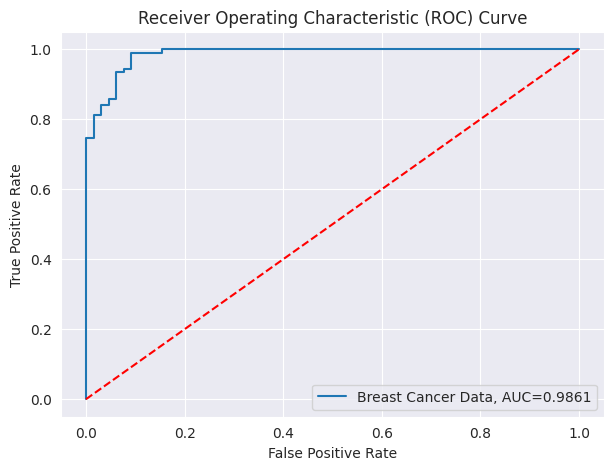

In [20]:
auc = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"Breast Cancer Data, AUC={auc:.4f}")
plt.plot([0, 1], [0, 1], color='red', linestyle='--') # Garis diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc=4)
plt.show()